In [28]:
!pip -q install kagglehub

import kagglehub
import os

dataset_path = kagglehub.dataset_download("grassknoted/asl-alphabet")

print("Dataset downloaded to:")
print(dataset_path)

print("\nDataset contents:")
print(os.listdir(dataset_path))

train_data_dir = os.path.join(
    dataset_path,
    "asl_alphabet_train",
    "asl_alphabet_train"
)

print("\nTraining data path:")
print(train_data_dir)

Using Colab cache for faster access to the 'asl-alphabet' dataset.
Dataset downloaded to:
/kaggle/input/asl-alphabet

Dataset contents:
['asl_alphabet_test', 'asl_alphabet_train']

Training data path:
/kaggle/input/asl-alphabet/asl_alphabet_train/asl_alphabet_train


In [29]:
import os
import matplotlib.pyplot as plt
from PIL import Image

In [30]:
data_dir=train_data_dir
classes=sorted(os.listdir(data_dir))

In [31]:
len_classes=len(classes)

In [32]:
for cls in classes[:5]:
    count=len(os.listdir(os.path.join(data_dir,cls)))
    print(f"{cls} {count}")

A 3000
B 3000
C 3000
D 3000
E 3000


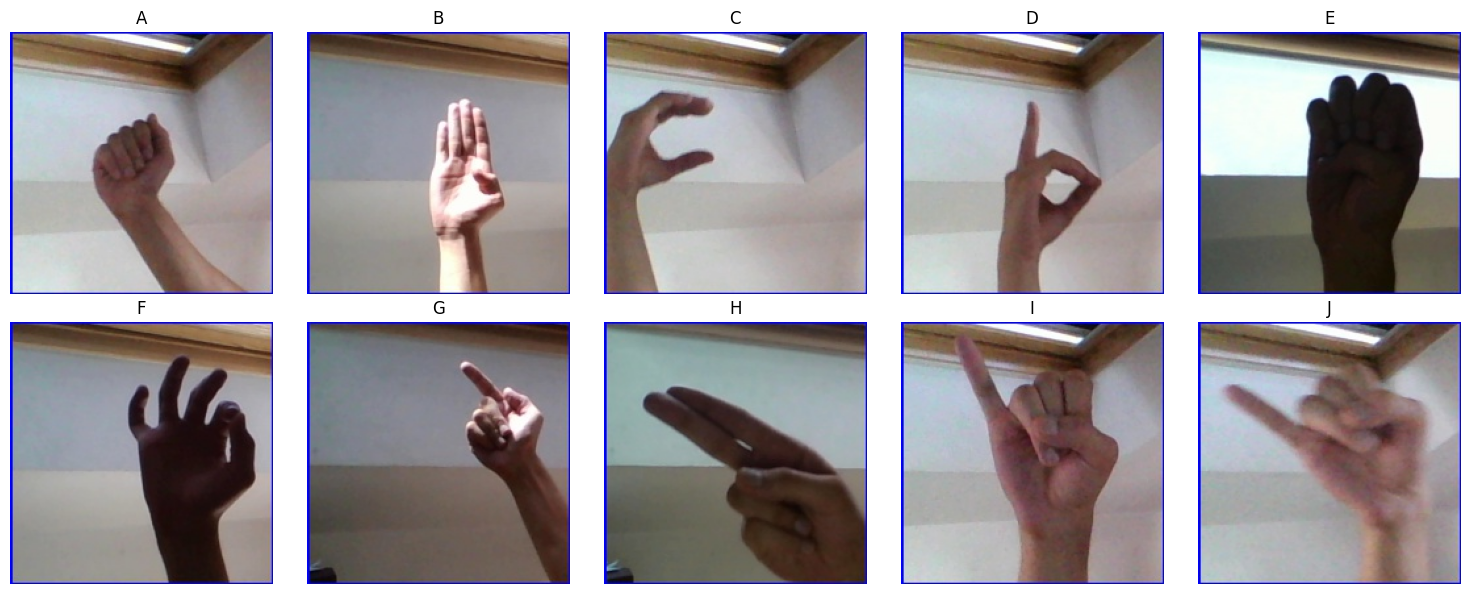

In [33]:
fig,axes=plt.subplots(2,5, figsize=(15,6))
sample_classes=classes[:10]

for ax,cls in zip(axes.flat,sample_classes):
    img_path=os.path.join(data_dir, cls,os.listdir(os.path.join(data_dir,cls))[0])
    img=Image.open(img_path)
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [57]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory

IMAGE_SIZE=(64,64)
BATCH_SIZE=64

train_df=image_dataset_from_directory(
    data_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=42,
    validation_split=0.2,
    subset='training',
)

val_df=image_dataset_from_directory(
    data_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    seed=42,
    subset='validation'

)

class_names=train_df.class_names
class_names

Found 87000 files belonging to 29 classes.
Using 69600 files for training.
Found 87000 files belonging to 29 classes.
Using 17400 files for validation.


['A',
 'B',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'J',
 'K',
 'L',
 'M',
 'N',
 'O',
 'P',
 'Q',
 'R',
 'S',
 'T',
 'U',
 'V',
 'W',
 'X',
 'Y',
 'Z',
 'del',
 'nothing',
 'space']

In [35]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    RandomRotation,
    RandomZoom,
    RandomBrightness,
    RandomContrast,
    Rescaling,
    Conv2D,
    MaxPool2D,
    Flatten,
    Dense,
    Dropout
)

model_cnn = Sequential([
    Input(shape=(64, 64, 3)),

    RandomRotation(0.1),
    RandomZoom(0.15),
    RandomBrightness(0.2),
    RandomContrast(0.2),

    Rescaling(1./255),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPool2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPool2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPool2D(2, 2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.4),

    Dense(len(class_names), activation='softmax')
])

model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_cnn.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation_2               │ (None, 64, 64, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_2 (RandomZoom)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness_2             │ (None, 64, 64, 3)      │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_2               │ (None, 64, 64, 3)      │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,101 (1.35 MB)

 Trainable params: 355,101 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    'model_cnn.keras',
    save_best_only=True,
    monitor='val_accuracy'
)

In [37]:
history = model_cnn.fit(
    train_df,
    validation_data=val_df,
    epochs=20,
    callbacks=[early_stop, model_checkpoint],
    verbose=1
)

Epoch 1/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 80s 72ms/step - accuracy: 0.3613 - loss: 2.1101 - val_accuracy: 0.7506 - val_loss: 0.8418
Epoch 2/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 78s 71ms/step - accuracy: 0.6437 - loss: 1.0706 - val_accuracy: 0.8662 - val_loss: 0.4505
Epoch 3/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 78s 71ms/step - accuracy: 0.7384 - loss: 0.7594 - val_accuracy: 0.9047 - val_loss: 0.2941
Epoch 4/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 84s 77ms/step - accuracy: 0.7941 - loss: 0.5945 - val_accuracy: 0.9390 - val_loss: 0.2047
Epoch 5/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 78s 72ms/step - accuracy: 0.8257 - loss: 0.5002 - val_accuracy: 0.9548 - val_loss: 0.1460
Epoch 6/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 77s 71ms/step - accuracy: 0.8490 - loss: 0.4264 - val_accuracy: 0.9656 - val_loss: 0.1177
Epoch 7/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 77s 71ms/step - accuracy: 0.8649 - loss: 0.3870 - val_accuracy: 0.9681 - val_loss: 0.0981
Epoch 8/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 80s 74ms/step - accuracy: 0.8788 -

In [60]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_df:
    predictions = model_cnn(images, training=False)
    predictions = tf.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predictions.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

           A       0.99      1.00      1.00       623
           B       1.00      1.00      1.00       634
           C       1.00      1.00      1.00       601
           D       1.00      1.00      1.00       643
           E       0.99      0.99      0.99       548
           F       1.00      1.00      1.00       646
           G       0.99      1.00      1.00       612
           H       1.00      0.99      0.99       626
           I       1.00      0.99      0.99       607
           J       1.00      1.00      1.00       626
           K       0.99      0.99      0.99       553
           L       1.00      1.00      1.00       593
           M       0.98      0.99      0.99       594
           N       0.99      0.98      0.99       555
           O       1.00      1.00      1.00       595
           P       0.99      0.99      0.99       606
           Q       0.99      1.00      0.99       636
           R       0.99    

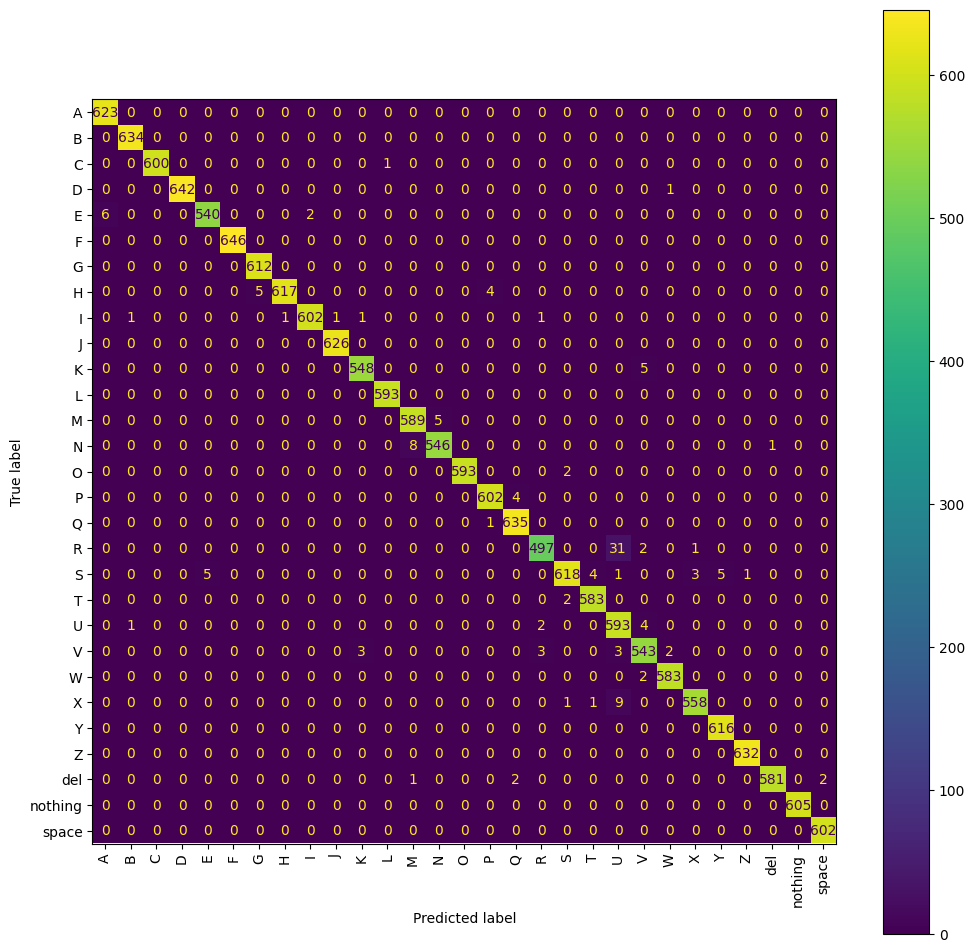

In [62]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=range(len(class_names))
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(12, 12))

disp.plot(
    ax=ax,
    xticks_rotation='vertical'
)

plt.show()

In [44]:
model_cnn.save('sign_language_model.keras')
import joblib
joblib.dump(class_names, 'sign_class_names.pkl')

['sign_class_names.pkl']